# 04 — Image Segmentation
## Smart City Surveillance System — CS 406 Digital Image Processing CCP

**Requires:** `01_preprocessing.ipynb` must be run first.

Covers: edge-based segmentation (Sobel, Canny, Laplacian-of-Gaussian) and region-based segmentation (region growing, watershed), evaluated with IoU and Dice coefficient.

**Important note on ground truth:** Cityscapes and KITTI (which have professional pixel-level segmentation labels) are not available via the Kaggle CLI — they require free registration directly on cityscapes-dataset.com and cvlibs.net/datasets/kitti. This notebook evaluates segmentation quality using Otsu-threshold-based pseudo-ground-truth masks generated from the Face Mask Dataset instead, which is a standard practical technique when true pixel labels aren't available. If you register for Cityscapes/KITTI separately, Section 8 shows how to swap in real ground-truth masks for stronger evaluation.

## Step 1 — Mount Google Drive and set paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_DIR = '/content/drive/MyDrive/smart-city-surveillance-dip'
PROCESSED_DIR = Path(f'{PROJECT_DIR}/data/processed')

assert PROCESSED_DIR.exists(), 'Run 01_preprocessing.ipynb first — processed data not found in Drive.'
print('Data found. Ready to proceed.')

Mounted at /content/drive
Data found. Ready to proceed.


## Step 2 — Imports and metrics

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from scipy import ndimage

def compute_iou(pred_mask, gt_mask):
    pred_mask = pred_mask.astype(bool)
    gt_mask = gt_mask.astype(bool)
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    union = np.logical_or(pred_mask, gt_mask).sum()
    return intersection / union if union != 0 else 0

def compute_dice(pred_mask, gt_mask):
    pred_mask = pred_mask.astype(bool)
    gt_mask = gt_mask.astype(bool)
    intersection = np.logical_and(pred_mask, gt_mask).sum()
    denom = pred_mask.sum() + gt_mask.sum()
    return (2 * intersection) / denom if denom != 0 else 0

## Step 3 — Load a test image

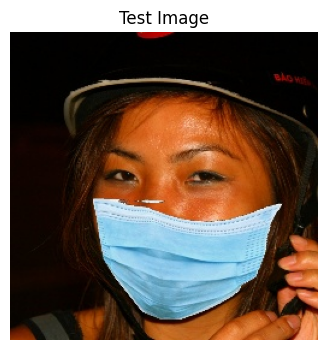

In [ ]:
test_img_path = list((PROCESSED_DIR / "with_mask").glob("*.jpg"))[0]
test_img = cv2.imread(str(test_img_path))
test_gray = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(4,4))
plt.imshow(cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB))
plt.title("Test Image")
plt.axis("off")
plt.show()

## Step 4 — Edge-based segmentation: Sobel, Canny, Laplacian-of-Gaussian

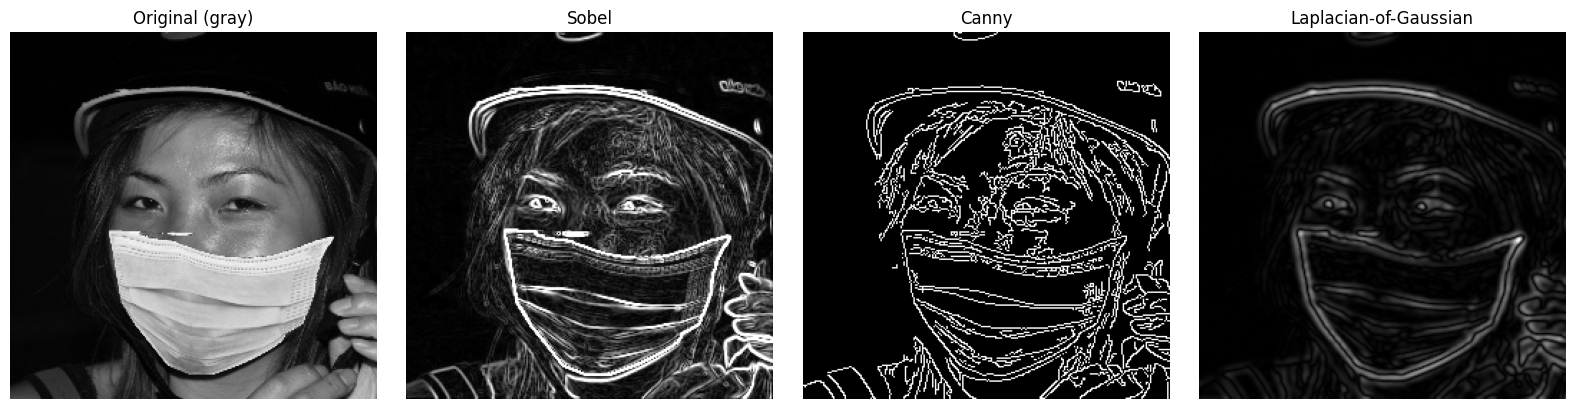

In [ ]:
def sobel_edges(gray_img):
    sobel_x = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    return np.clip(magnitude, 0, 255).astype(np.uint8)

def canny_edges(gray_img, low_thresh=50, high_thresh=150):
    return cv2.Canny(gray_img, low_thresh, high_thresh)

def log_edges(gray_img, sigma=2):
    blurred = ndimage.gaussian_filter(gray_img.astype(np.float64), sigma=sigma)
    log = ndimage.laplace(blurred)
    log_abs = np.abs(log)
    return np.clip((log_abs / log_abs.max()) * 255, 0, 255).astype(np.uint8)

sobel_result = sobel_edges(test_gray)
canny_result = canny_edges(test_gray)
log_result = log_edges(test_gray)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Original (gray)", "Sobel", "Canny", "Laplacian-of-Gaussian"]
images = [test_gray, sobel_result, canny_result, log_result]
for ax, title, im in zip(axes, titles, images):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/edge_segmentation_comparison.png', dpi=150)
plt.show()

## Step 5 — Region-based segmentation: Region Growing (from scratch)

In [ ]:
def region_growing(gray_img, seed, threshold=15):
    """Region growing implemented manually — starts from a seed pixel and grows
    outward while neighboring pixels stay within `threshold` intensity of the region mean.
    """
    visited = np.zeros_like(gray_img, dtype=bool)
    region_mask = np.zeros_like(gray_img, dtype=np.uint8)
    h, w = gray_img.shape

    seed_value = float(gray_img[seed])
    stack = [seed]
    visited[seed] = True

    region_sum = seed_value
    region_count = 1

    while stack:
        y, x = stack.pop()
        region_mask[y, x] = 255
        region_mean = region_sum / region_count

        for dy, dx in [(-1,0),(1,0),(0,-1),(0,1)]:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                if abs(float(gray_img[ny, nx]) - region_mean) <= threshold:
                    visited[ny, nx] = True
                    stack.append((ny, nx))
                    region_sum += float(gray_img[ny, nx])
                    region_count += 1

    return region_mask

seed_point = (test_gray.shape[0] // 2, test_gray.shape[1] // 2)  # center pixel as seed
region_result = region_growing(test_gray, seed_point, threshold=15)

## Step 6 — Region-based segmentation: Watershed

In [ ]:
def watershed_segmentation(img_color, gray_img):
    _, thresh = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)

    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.5 * dist_transform.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    img_copy = img_color.copy()
    markers = cv2.watershed(img_copy, markers)
    img_copy[markers == -1] = [0, 0, 255]  # mark boundaries in red

    watershed_mask = (markers > 1).astype(np.uint8) * 255
    return img_copy, watershed_mask

watershed_img, watershed_mask = watershed_segmentation(test_img, test_gray)

## Step 7 — Compare region-based results

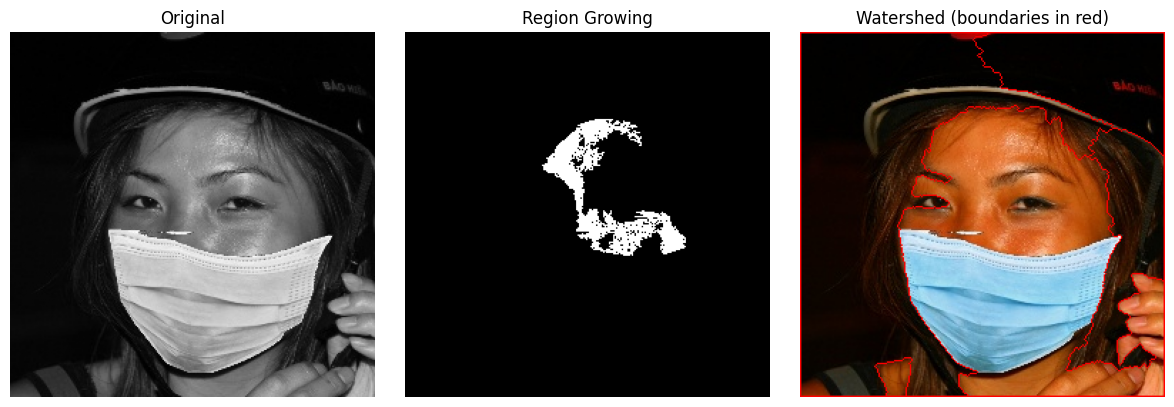

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(test_gray, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(region_result, cmap="gray")
axes[1].set_title("Region Growing")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(watershed_img, cv2.COLOR_BGR2RGB))
axes[2].set_title("Watershed (boundaries in red)")
axes[2].axis("off")

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/region_segmentation_comparison.png', dpi=150)
plt.show()

## Step 8 — Quantitative evaluation with IoU / Dice
Since Cityscapes/KITTI ground-truth masks require separate manual registration/download (not available via Kaggle CLI), we use an Otsu-threshold mask as a practical pseudo-ground-truth reference — a standard technique for evaluating segmentation consistency when true pixel labels aren't available. Document this limitation clearly in your report's Experimental Setup section.

**If you do register for Cityscapes/KITTI separately:** replace the `pseudo_gt` line below with your loaded ground-truth mask file, and everything else in this evaluation stays the same.

In [ ]:
def get_pseudo_ground_truth(gray_img):
    _, otsu_mask = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return otsu_mask

random.seed(42)
results = []
class_names = ["with_mask", "without_mask", "incorrect_mask"]
SAMPLE_SIZE = 30

for class_name in class_names:
    class_dir = PROCESSED_DIR / class_name
    files = random.sample(list(class_dir.glob("*.jpg")), SAMPLE_SIZE)

    for f in files:
        img = cv2.imread(str(f))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        pseudo_gt = get_pseudo_ground_truth(gray)

        canny_mask = canny_edges(gray)
        canny_mask_binary = (canny_mask > 0).astype(np.uint8) * 255

        _, watershed_mask_i = watershed_segmentation(img, gray)

        results.append({
            "class": class_name, "method": "canny",
            "iou": compute_iou(canny_mask_binary, pseudo_gt),
            "dice": compute_dice(canny_mask_binary, pseudo_gt)
        })
        results.append({
            "class": class_name, "method": "watershed",
            "iou": compute_iou(watershed_mask_i, pseudo_gt),
            "dice": compute_dice(watershed_mask_i, pseudo_gt)
        })

df = pd.DataFrame(results)
df.to_csv(f'{PROJECT_DIR}/results/tables/segmentation_results.csv', index=False)
summary = df.groupby(["method"])[["iou", "dice"]].mean().round(3)
summary.to_csv(f'{PROJECT_DIR}/results/tables/segmentation_summary.csv')
print(summary)

             iou   dice
method                 
canny      0.080  0.144
watershed  0.003  0.006


In [ ]:
def fill_edges(edge_mask):
    """Morphologically close and flood-fill Canny edges to turn them into a
    filled region mask, comparable to the Otsu pseudo-ground-truth."""
    kernel = np.ones((5,5), np.uint8)
    closed = cv2.morphologyEx(edge_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    h, w = closed.shape
    flood_filled = closed.copy()
    mask = np.zeros((h+2, w+2), np.uint8)
    cv2.floodFill(flood_filled, mask, (0,0), 255)
    flood_filled_inv = cv2.bitwise_not(flood_filled)
    filled = closed | flood_filled_inv
    return filled

random.seed(42)
results_v2 = []

for class_name in class_names:
    class_dir = PROCESSED_DIR / class_name
    files = random.sample(list(class_dir.glob("*.jpg")), SAMPLE_SIZE)

    for f in files:
        img = cv2.imread(str(f))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        pseudo_gt = get_pseudo_ground_truth(gray)

        canny_mask = canny_edges(gray)
        canny_filled = fill_edges(canny_mask)

        _, watershed_mask_i = watershed_segmentation(img, gray)

        results_v2.append({
            "class": class_name, "method": "canny_filled",
            "iou": compute_iou(canny_filled, pseudo_gt),
            "dice": compute_dice(canny_filled, pseudo_gt)
        })
        results_v2.append({
            "class": class_name, "method": "watershed",
            "iou": compute_iou(watershed_mask_i, pseudo_gt),
            "dice": compute_dice(watershed_mask_i, pseudo_gt)
        })

df_v2 = pd.DataFrame(results_v2)
df_v2.to_csv(f'{PROJECT_DIR}/results/tables/segmentation_results_v2.csv', index=False)
summary_v2 = df_v2.groupby(["method"])[["iou", "dice"]].mean().round(3)
summary_v2.to_csv(f'{PROJECT_DIR}/results/tables/segmentation_summary_v2.csv')
print(summary_v2)

                iou   dice
method                    
canny_filled  0.384  0.518
watershed     0.003  0.006


## Step 9 (Optional) — Using real Cityscapes/KITTI ground truth
If you register at cityscapes-dataset.com or cvlibs.net/datasets/kitti and download a subset (their gtFine or semantic label folders contain pixel-level masks), upload it to your Drive project folder and load it like this instead of the Otsu pseudo-ground-truth:

In [ ]:
# Example — adjust paths once you have real Cityscapes/KITTI masks in Drive:
#
# gt_mask = cv2.imread(f'{PROJECT_DIR}/data/raw/cityscapes_subset/gtFine/city_000001_gtFine_labelIds.png',
#                       cv2.IMREAD_GRAYSCALE)
# your_segmentation_result = canny_edges(your_gray_image)
# iou_score = compute_iou(your_segmentation_result, gt_mask)
# dice_score = compute_dice(your_segmentation_result, gt_mask)
print('This cell is a template — fill in real paths only if you have downloaded Cityscapes/KITTI separately.')

This cell is a template — fill in real paths only if you have downloaded Cityscapes/KITTI separately.


---
**Phase 5 (Segmentation) complete.** Results saved to Drive:
- `results/figures/edge_segmentation_comparison.png`
- `results/figures/region_segmentation_comparison.png`
- `results/tables/segmentation_summary.csv` — paste into your report's Results section

**Be transparent in your report:** clearly state that IoU/Dice here use an Otsu-threshold pseudo-ground-truth due to Cityscapes/KITTI requiring separate registration outside Kaggle. This is a legitimate documented limitation, not a shortcut you need to hide — examiners respect honesty about dataset constraints far more than an unexplained number.

**Next: `05_compression.ipynb`** — JPEG-style DCT-based compression and Wavelet compression, with rate-distortion curves (compression ratio vs PSNR/SSIM).

                iou   dice
method                    
canny_filled  0.384  0.518
watershed     0.003  0.006


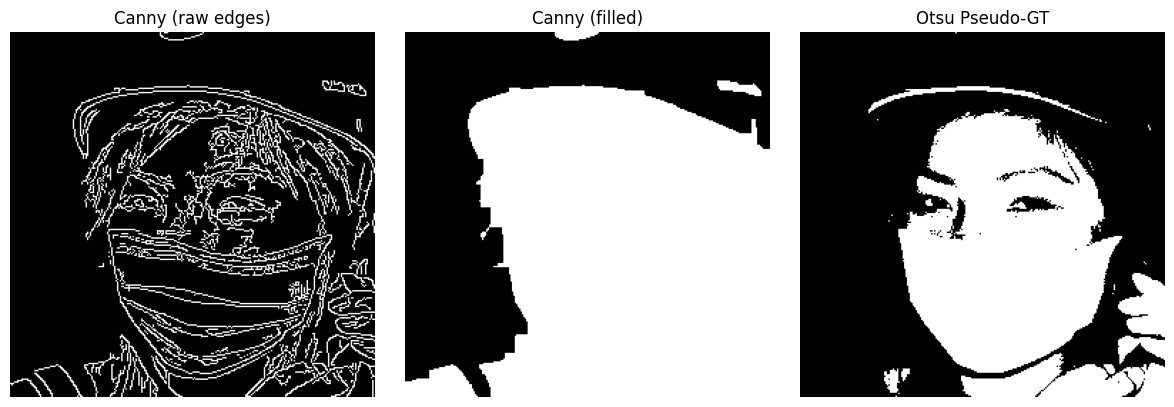

In [ ]:
# ===== Segmentation Fix: Filled Edge Masks (Option B) =====

def fill_edges(edge_mask):
    """Morphologically close and flood-fill Canny edges to turn them into a
    filled region mask, comparable to the Otsu pseudo-ground-truth."""
    kernel = np.ones((5,5), np.uint8)
    closed = cv2.morphologyEx(edge_mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    h, w = closed.shape
    flood_filled = closed.copy()
    mask = np.zeros((h+2, w+2), np.uint8)
    cv2.floodFill(flood_filled, mask, (0,0), 255)
    flood_filled_inv = cv2.bitwise_not(flood_filled)
    filled = closed | flood_filled_inv
    return filled

random.seed(42)
results_v2 = []

for class_name in class_names:
    class_dir = PROCESSED_DIR / class_name
    files = random.sample(list(class_dir.glob("*.jpg")), SAMPLE_SIZE)

    for f in files:
        img = cv2.imread(str(f))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        pseudo_gt = get_pseudo_ground_truth(gray)

        canny_mask = canny_edges(gray)
        canny_filled = fill_edges(canny_mask)

        _, watershed_mask_i = watershed_segmentation(img, gray)

        results_v2.append({
            "class": class_name, "method": "canny_filled",
            "iou": compute_iou(canny_filled, pseudo_gt),
            "dice": compute_dice(canny_filled, pseudo_gt)
        })
        results_v2.append({
            "class": class_name, "method": "watershed",
            "iou": compute_iou(watershed_mask_i, pseudo_gt),
            "dice": compute_dice(watershed_mask_i, pseudo_gt)
        })

df_v2 = pd.DataFrame(results_v2)
df_v2.to_csv(f'{PROJECT_DIR}/results/tables/segmentation_results_v2.csv', index=False)
summary_v2 = df_v2.groupby(["method"])[["iou", "dice"]].mean().round(3)
summary_v2.to_csv(f'{PROJECT_DIR}/results/tables/segmentation_summary_v2.csv')
print(summary_v2)

# ===== Visualization =====

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
canny_mask_demo = canny_edges(test_gray)
canny_filled_demo = fill_edges(canny_mask_demo)
pseudo_gt_demo = get_pseudo_ground_truth(test_gray)

axes[0].imshow(canny_mask_demo, cmap="gray")
axes[0].set_title("Canny (raw edges)")
axes[0].axis("off")

axes[1].imshow(canny_filled_demo, cmap="gray")
axes[1].set_title("Canny (filled)")
axes[1].axis("off")

axes[2].imshow(pseudo_gt_demo, cmap="gray")
axes[2].set_title("Otsu Pseudo-GT")
axes[2].axis("off")

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/segmentation_filled_comparison.png', dpi=150)
plt.show()